# Projet Machine Learning : Prédiction de la météo

Imports de certains package nécessaire

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import naive_bayes,svm
from sklearn.svm import SVC
from sklearn.metrics import f1_score, ConfusionMatrixDisplay, classification_report
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

Import des données et remplacement des target vide par soleil

*Question* : Est ce que toutes les valeurs manquantes sont des soleils ?

In [16]:
df = pd.read_csv('data/madrid_meteo_data.csv')

df.loc[df[' Events'].isnull(), ' Events'] = 'Sun' 

print(df.columns)



Index(['CET', 'Max TemperatureC', 'Mean TemperatureC', 'Min TemperatureC',
       'Dew PointC', 'MeanDew PointC', 'Min DewpointC', 'Max Humidity',
       ' Mean Humidity', ' Min Humidity', ' Max Sea Level PressurehPa',
       ' Mean Sea Level PressurehPa', ' Min Sea Level PressurehPa',
       ' Max VisibilityKm', ' Mean VisibilityKm', ' Min VisibilitykM',
       ' Max Wind SpeedKm/h', ' Mean Wind SpeedKm/h', ' Max Gust SpeedKm/h',
       'Precipitationmm', ' CloudCover', ' Events', 'WindDirDegrees'],
      dtype='object')


*CHOIX 1* : Supprimer les lignes avec des valeurs manquantes (sauf pour Max Gust SpeedKm/h)

Et supprimer les lignes avec des y trop rares (moins de 10 occurrences)

In [ ]:
#colonnes qui me paraissent inutiles pour la prédiction de l'événement météo
X = df.drop(columns=['CET', 'WindDirDegrees'], axis=1)

# Pour les rafales de vent, on remplace les valeurs manquantes par 0 (pas de rafales)
X[' Max Gust SpeedKm/h'] = X[' Max Gust SpeedKm/h'].fillna(0)

X.dropna(inplace=True) 

etiquettes_drop = X[' Events'].value_counts()[X[' Events'].value_counts() < 10].index
X.drop(X[X[' Events'].isin(etiquettes_drop)].index, inplace=True)

Y = X[' Events']
X.drop(columns=[' Events'], inplace=True)    # 5400 lignes gardées sur 6800

print ( 'nombre d occurrences de chaque classe : \n', Y.value_counts(normalize=True)* len(Y), '\n\n')

nombre d occurrences de chaque classe : 
  Events
Sun                  3653.0
Rain                 1140.0
Rain-Thunderstorm     247.0
Fog                   221.0
Fog-Rain               69.0
Thunderstorm           45.0
Rain-Snow              33.0
Snow                   14.0
Name: proportion, dtype: float64 




Premier modèle  : XG boost sans paramètres

In [58]:
# 70% apprentissage, 30% temporaire
X_app, X_temp, Y_app, Y_temp = train_test_split(
    X, Y,
    test_size=0.30,
    random_state=42,
    shuffle=True)

# Diviser les 30% restants en 15% validation et 15% test
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp,
    test_size=0.50,
    random_state=42,
    shuffle=True)

# Transformer les étiquettes de classes en entiers
le = LabelEncoder()
Y_app_encoded = le.fit_transform(Y_app)
Y_val_encoded = le.transform(Y_val)
Y_test_encoded = le.transform(Y_test)

# Poids pour chaque classe car les classes sont déséquilibrées
weights = compute_sample_weight(
    class_weight="balanced",
    y=Y_app_encoded)

mod  =xgb.XGBClassifier()
mod.fit(X_app, Y_app_encoded, sample_weight=weights)

Y_pred = mod.predict(X_test)

# Resultats du modèle sur le jeu de test
print(classification_report(
        Y_test_encoded,
        Y_pred,
        target_names=le.classes_))


                   precision    recall  f1-score   support

              Fog       0.55      0.69      0.61        32
         Fog-Rain       0.20      0.14      0.17        14
             Rain       0.61      0.72      0.66       161
        Rain-Snow       0.40      0.33      0.36         6
Rain-Thunderstorm       0.38      0.32      0.35        34
             Snow       0.00      0.00      0.00         2
              Sun       0.91      0.88      0.89       553
     Thunderstorm       0.40      0.17      0.24        12

         accuracy                           0.79       814
        macro avg       0.43      0.41      0.41       814
     weighted avg       0.79      0.79      0.79       814



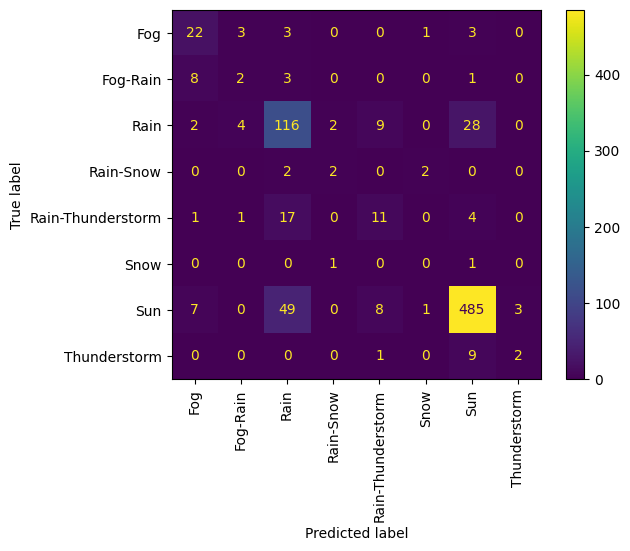

In [8]:
ConfusionMatrixDisplay.from_predictions(
    Y_test_encoded,
    Y_pred,
    display_labels=le.classes_,
    xticks_rotation=90)

Deuxième référence : il fait le meme temps qu'hier

In [56]:
Y_ref = df[' Events']
Y_ref_pred = df[' Events'].copy()
Y_ref_pred = np.insert(Y_ref_pred.values, 0, 'Sun')  # Ajouter une valeur fictive pour la première ligne
Y_ref_pred = Y_ref_pred[:-1]  # Supprimer la dernière valeur pour conserver

le = LabelEncoder()

Y_app_encoded = le.fit_transform(Y_ref)
Y_pred_encoded = le.transform(Y_ref_pred)

print(classification_report(
        Y_app_encoded, Y_pred_encoded, target_names=le.classes_))




                        precision    recall  f1-score   support

                   Fog       0.27      0.27      0.27       233
              Fog-Rain       0.13      0.13      0.13        69
         Fog-Rain-Snow       0.00      0.00      0.00         1
 Fog-Rain-Thunderstorm       0.00      0.00      0.00         1
              Fog-Snow       0.25      0.25      0.25         4
      Fog-Thunderstorm       0.00      0.00      0.00         1
                  Rain       0.43      0.43      0.43      1140
             Rain-Hail       0.00      0.00      0.00         1
Rain-Hail-Thunderstorm       0.00      0.00      0.00         7
             Rain-Snow       0.12      0.12      0.12        33
Rain-Snow-Thunderstorm       0.00      0.00      0.00         1
     Rain-Thunderstorm       0.22      0.22      0.22       247
                  Snow       0.07      0.07      0.07        14
                   Sun       0.84      0.84      0.84      5014
          Thunderstorm       0.09      

Visualisation des données par histogrammes en fonction de chacune des colonnes

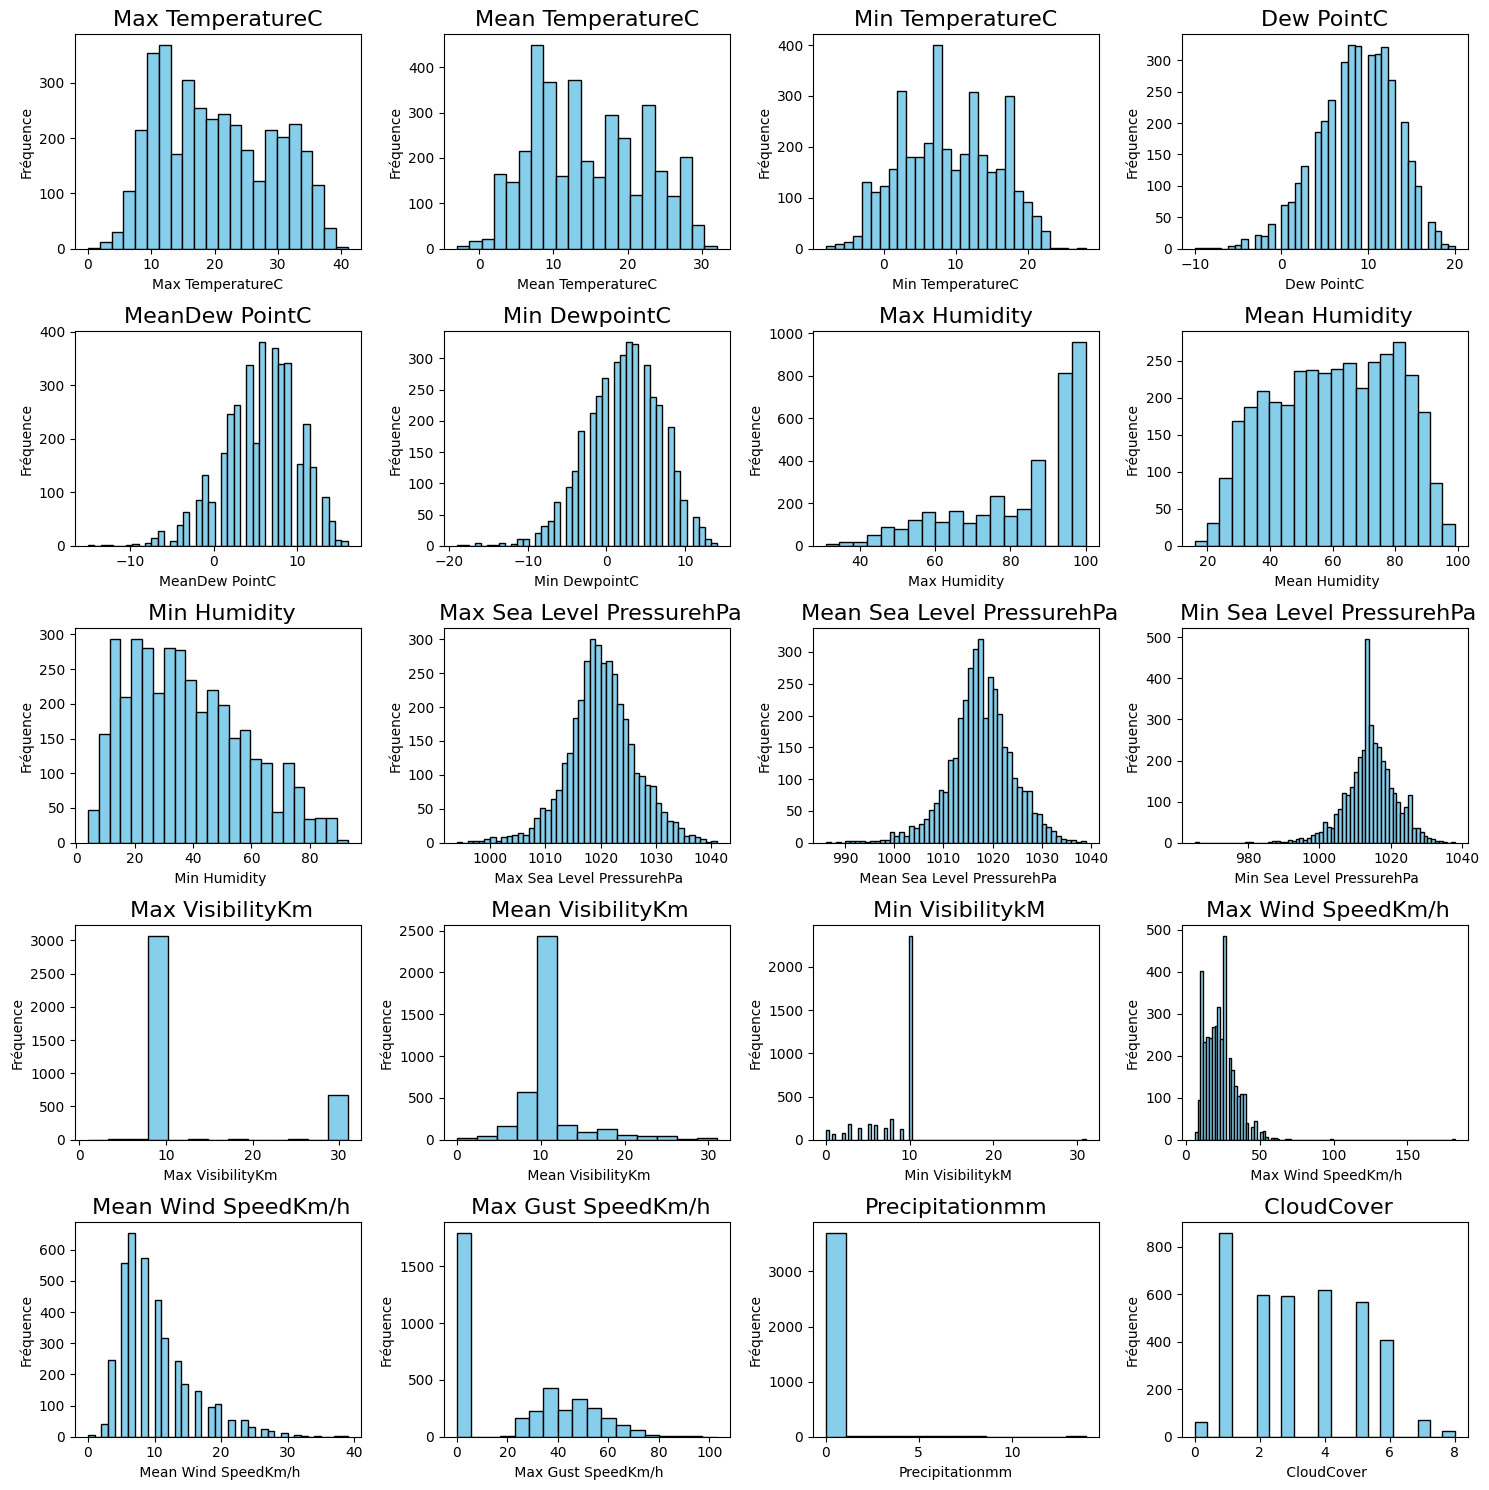

In [36]:
ncol = X_app.shape[1]
fig, axes = plt.subplots(5, 4, figsize=(15, 15))

# faire un histogramme des colonnes numériques pour visualiser la distribution des données
axes = axes.ravel()

# Faire un histogramme pour chaque colonne
for i, col in enumerate(X_app.columns):
    axes[i].hist(X_app[col], bins='auto', color='skyblue', edgecolor='black')
    axes[i].set_title(f'{col}', fontsize=16)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()


Remarques : 

Gust speed : soit pas de rafales soit des rafales : un colonne avec 1-0 ?

Beaucoup de moment avec Precipitation 0 : importance des moment ou precipitation != 0

Max visibility en deux parties soit 30 km soit 9 km


# Test 2 : SVC

                   precision    recall  f1-score   support

              Fog       0.54      0.69      0.60        32
         Fog-Rain       0.23      0.64      0.33        14
             Rain       0.53      0.55      0.54       161
        Rain-Snow       0.50      0.17      0.25         6
Rain-Thunderstorm       0.23      0.59      0.33        34
             Snow       0.25      0.50      0.33         2
              Sun       0.95      0.69      0.80       553
     Thunderstorm       0.08      0.50      0.14        12

         accuracy                           0.65       814
        macro avg       0.41      0.54      0.42       814
     weighted avg       0.79      0.65      0.70       814



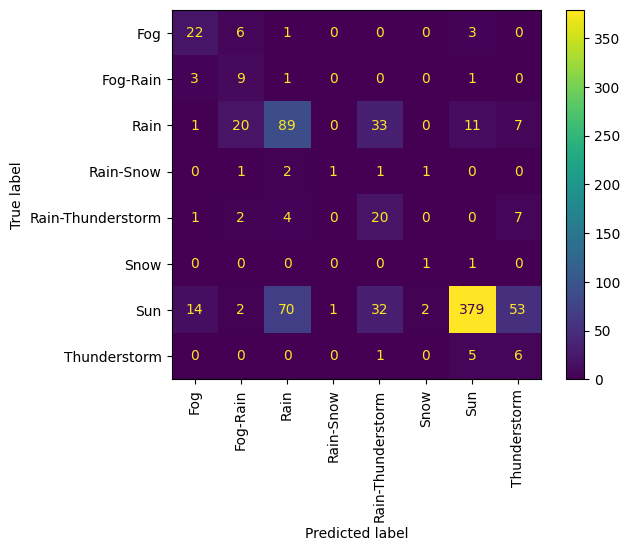

In [60]:
mod = SVC(kernel='linear', class_weight='balanced', random_state=42)

mod.fit(X_app, Y_app_encoded)

Y_pred = mod.predict(X_test) 

# Resultats du modèle sur le jeu de test
print(classification_report(
        Y_test_encoded,
        Y_pred,
        target_names=le.classes_))

ConfusionMatrixDisplay.from_predictions(
    Y_test_encoded,
    Y_pred,
    display_labels=le.classes_,
    xticks_rotation=90)

Au niveau des autres modèles de SVC j'ai des très mauvais résultats peut être à cause d'hyperparamètres mal choisis

J'applique les changements de colonne que j'ai trouvé pertinent en regardant les histogrammes

In [55]:
# une colonne Gust
X_app['Gust'] = np.where(X_app[' Max Gust SpeedKm/h'] > 0, 1, 0)
X_val['Gust'] = np.where(X_val[' Max Gust SpeedKm/h'] > 0, 1, 0)
X_test['Gust'] = np.where(X_test[' Max Gust SpeedKm/h'] > 0, 1, 0)

# 3 colonnes en one hot encoding pour max visibility

X_app['no_visibility'] = np.where(X_app[' Max VisibilityKm'] < 7, 1, 0)
X_val['no_visibility'] = np.where(X_val[' Max VisibilityKm'] < 7, 1, 0)
X_test['no_visibility'] = np.where(X_test[' Max VisibilityKm'] < 7, 1, 0)

X_app['low_visibility'] = np.where((X_app[' Max VisibilityKm'] >= 7) & (X_app[' Max VisibilityKm'] < 15), 1, 0)
X_val['low_visibility'] = np.where((X_val[' Max VisibilityKm'] >= 7) & (X_val[' Max VisibilityKm'] < 15), 1, 0)
X_test['low_visibility'] = np.where((X_test[' Max VisibilityKm'] >= 7) & (X_test[' Max VisibilityKm'] < 15), 1, 0)

X_app['high_visibility'] = np.where(X_app[' Max VisibilityKm'] >= 15, 1, 0)
X_val['high_visibility'] = np.where(X_val[' Max VisibilityKm'] >= 15, 1, 0)
X_test['high_visibility'] = np.where(X_test[' Max VisibilityKm'] >= 15, 1, 0)

# est ce qu'il a plu ?
X_app['is_raining'] = np.where(X_app['Precipitationmm'] > 0, 1, 0)
X_val['is_raining'] = np.where(X_val['Precipitationmm'] > 0, 1, 0)
X_test['is_raining'] = np.where(X_test['Precipitationmm'] > 0, 1, 0)

mod.fit(X_app, Y_app_encoded)

Y_pred = mod.predict(X_test) 

# Resultats du modèle sur le jeu de test
print(classification_report(
        Y_test_encoded,
        Y_pred,
        target_names=le.classes_))



                   precision    recall  f1-score   support

              Fog       0.49      0.62      0.55        32
         Fog-Rain       0.17      0.50      0.26        14
             Rain       0.55      0.58      0.56       161
        Rain-Snow       0.50      0.17      0.25         6
Rain-Thunderstorm       0.24      0.56      0.34        34
             Snow       0.25      0.50      0.33         2
              Sun       0.95      0.70      0.80       553
     Thunderstorm       0.10      0.58      0.17        12

         accuracy                           0.66       814
        macro avg       0.41      0.53      0.41       814
     weighted avg       0.79      0.66      0.70       814



Normalisation des données

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_app_scaled = scaler.fit_transform(X_app)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

mod.fit(X_app_scaled, Y_app_encoded)

Y_pred = mod.predict(X_test_scaled) 

# Resultats du modèle sur le jeu de test
print(classification_report(
        Y_test_encoded,
        Y_pred,
        target_names=le.classes_))

                   precision    recall  f1-score   support

              Fog       0.48      0.66      0.55        32
         Fog-Rain       0.18      0.57      0.27        14
             Rain       0.53      0.54      0.54       161
        Rain-Snow       0.33      0.17      0.22         6
Rain-Thunderstorm       0.21      0.47      0.29        34
             Snow       0.09      0.50      0.15         2
              Sun       0.96      0.66      0.78       553
     Thunderstorm       0.09      0.67      0.16        12

         accuracy                           0.62       814
        macro avg       0.36      0.53      0.37       814
     weighted avg       0.79      0.62      0.68       814



Je suis étonné il est moins bon une fois que les données sont normalisées

Pourquoi ???

Realisation d'une ACP

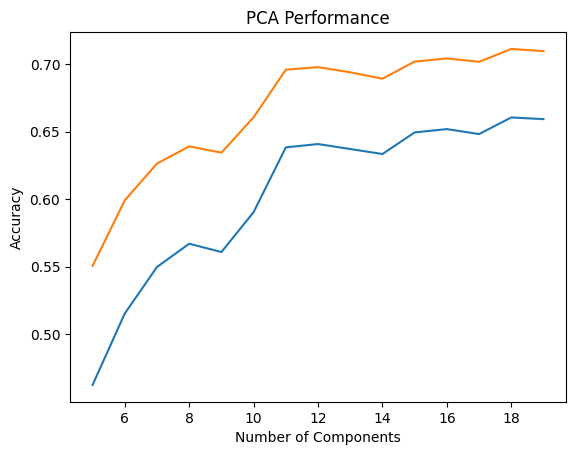

In [ ]:
from sklearn.decomposition import PCA
from sklearn import metrics

n_list = []
accuracy= []
f1_score_list = []

for n in range (5,20):
    pca = PCA(n_components= n)
    X_app_pca = pca.fit_transform(X_app_scaled)
    X_val_pca = pca.transform(X_val_scaled)

    mod.fit(X_app_pca, Y_app_encoded)
    Y_pred = mod.predict(X_val_pca)
    
    accuracy.append(metrics.accuracy_score(Y_val_encoded, Y_pred))
    f1_score_list.append(metrics.f1_score(Y_val_encoded, Y_pred, average='weighted'))

    n_list.append(n)

plt.plot(n_list, accuracy)
plt.plot(n_list, f1_score_list)
plt.xlabel('Number of Components')
plt.ylabel('Accuracy')
plt.title('PCA Performance')
plt.show()

    

    



Pour l'ACP on peut en conclure que n = 11 a l'air de suffire

Reste à faire : Voir si on peut gérer des hyperparamètres du modèle linéaire/XGboost pour une meilleure perf
